In [1]:
import os
print(os.getcwd())
import sys
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
 
try:
    import xgboost as xgb
except ImportError:
    print("❌  xgboost not found. Install with:  pip install xgboost")
    sys.exit(1)
 
warnings.filterwarnings("ignore")
 

c:\Users\Anvay Uparkar\Hackathon projects\AI_Health_prediction\project\models


In [2]:
# ─────────────────────────────────────────────────────────────────
# 1.  CONFIGURATION — change paths / hyper-params here
# ─────────────────────────────────────────────────────────────────
CSV_PATH = "Cardiovascular Diseases Risk Prediction Dataset export 2026-02-28 17-19-30.csv"
MODEL_DIR   = "saved_models"
RANDOM_SEED = 42
TEST_SIZE   = 0.20

# ── Improvement settings ────────────────────────────────────────
# Threshold range to search for best F1
THRESHOLD_MIN = 0.30
THRESHOLD_MAX = 0.80
THRESHOLD_STEP = 0.01

# Feature importance cutoff (drop features below this XGBoost importance)
FEATURE_IMPORTANCE_CUTOFF = 0.01   # set to 0 to keep all features

In [3]:
# ─────────────────────────────────────────────────────────────────
# 2. COLUMN DEFINITIONS (used for encoding + questionnaire)
# ─────────────────────────────────────────────────────────────────
TARGET = "Heart_Disease"
 
# Ordinal mappings  (order matters)
ORDINAL_MAPS = {
    "General_Health": {"Poor": 0, "Fair": 1, "Good": 2, "Very Good": 3, "Excellent": 4},
    "Checkup": {
        "Never": 0,
        "5 or more years ago": 1,
        "Within the past 5 years": 2,
        "Within the past 2 years": 3,
        "Within the past year": 4,
    },
    "Age_Category": {
        "18-24": 0, "25-29": 1, "30-34": 2, "35-39": 3, "40-44": 4,
        "45-49": 5, "50-54": 6, "55-59": 7, "60-64": 8, "65-69": 9,
        "70-74": 10, "75-79": 11, "80+": 12,
    },
    "Diabetes": {
        "No": 0,
        "No, pre-diabetes or borderline diabetes": 1,
        "Yes, but female told only during pregnancy": 2,
        "Yes": 3,
    },
}
 
# Binary Yes/No columns
BINARY_COLS = [
    "Exercise", "Skin_Cancer", "Other_Cancer", "Depression",
    "Arthritis", "Smoking_History"
]
 
# Sex encoding
SEX_MAP = {"Female": 0, "Male": 1}
 
NUMERIC_COLS = [
    "Height_(cm)", "Weight_(kg)", "BMI",
    "Alcohol_Consumption", "Fruit_Consumption",
    "Green_Vegetables_Consumption", "FriedPotato_Consumption",
]
 

In [4]:
# ─────────────────────────────────────────────────────────────────
# 3. DATA LOADING & PREPROCESSING
# ─────────────────────────────────────────────────────────────────
def load_and_preprocess(path: str):
    print(f"\n📂  Loading dataset from: {path}")
    df = pd.read_csv(path)
    print(f"    Shape: {df.shape}   |   Heart Disease prevalence: "
          f"{(df[TARGET]=='Yes').mean():.1%}")
 
    # --- Encode target
    df[TARGET] = (df[TARGET] == "Yes").astype(int)
 
    # --- Ordinal encoding
    for col, mapping in ORDINAL_MAPS.items():
        df[col] = df[col].map(mapping)
 
    # --- Binary Yes/No
    for col in BINARY_COLS:
        df[col] = (df[col] == "Yes").astype(int)
 
    # --- Sex
    df["Sex"] = df["Sex"].map(SEX_MAP)
 
    # --- Drop rows with any remaining NaN (from unmapped values)
    before = len(df)
    df.dropna(inplace=True)
    if len(df) < before:
        print(f"    ⚠  Dropped {before - len(df)} rows with unmapped / null values.")
 
    feature_cols = (
        list(ORDINAL_MAPS.keys()) + BINARY_COLS + ["Sex"] + NUMERIC_COLS
    )
    X = df[feature_cols].values.astype(np.float32)
    y = df[TARGET].values
 
    return X, y, feature_cols


In [5]:
# ─────────────────────────────────────────────────────────────────
# 4. TRAIN / EVALUATE  (IMPROVED VERSION)
# ─────────────────────────────────────────────────────────────────
#
# Key improvements over v1:
#   ✅ 1. Stacking meta-learner (LogisticRegression) instead of fixed blend
#   ✅ 2. Threshold optimised for F1 over a wider range
#   ✅ 3. scale_pos_weight already applied on XGBoost (class-imbalance fix)
#   ✅ 4. MLP trained with class_weight='balanced' (imbalance fix)
#   ✅ 5. Feature importance filtering – prune low-signal features
#   ✅ 6. Precision-Recall curve added to plots
#   ✅ 7. Reports F1, ROC-AUC, Precision, Recall clearly
# ─────────────────────────────────────────────────────────────────

def train_models(X, y, feature_cols):
    print("\n⚙️   Splitting data …")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
    )

    # ── Class imbalance info ─────────────────────────────────────
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos
    print(f"    Class distribution — Negative: {neg:,}  |  Positive: {pos:,}")
    print(f"    scale_pos_weight = {scale_pos_weight:.2f}")

    sample_weights = compute_sample_weight("balanced", y_train)

    # ── 4a. XGBoost ──────────────────────────────────────────────
    print("\n🌲  Training XGBoost (with scale_pos_weight) …")
    xgb_model = xgb.XGBClassifier(
        n_estimators        = 600,
        max_depth           = 5,
        learning_rate       = 0.05,
        subsample           = 0.8,
        colsample_bytree    = 0.8,
        min_child_weight    = 5,        # helps generalisation
        gamma               = 1,        # regularisation
        scale_pos_weight    = scale_pos_weight,
        use_label_encoder   = False,
        eval_metric         = "aucpr",  # PR-AUC better for imbalanced data
        random_state        = RANDOM_SEED,
        n_jobs              = -1,
        early_stopping_rounds = 40,
    )
    xgb_model.fit(
        X_train, y_train,
        sample_weight   = sample_weights,
        eval_set        = [(X_test, y_test)],
        verbose         = False,
    )

    # ── 4b. Feature Importance Filtering ─────────────────────────
    importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
    selected_features = importances[importances >= FEATURE_IMPORTANCE_CUTOFF].index.tolist()
    dropped = [f for f in feature_cols if f not in selected_features]
    if dropped:
        print(f"    🔍 Dropped low-importance features: {dropped}")
        feat_idx = [feature_cols.index(f) for f in selected_features]
        X_train_sel = X_train[:, feat_idx]
        X_test_sel  = X_test[:, feat_idx]
    else:
        print("    🔍 All features kept (all above importance cutoff)")
        selected_features = feature_cols
        X_train_sel = X_train
        X_test_sel  = X_test

    # Re-train XGBoost on selected features if any were dropped
    if dropped:
        print("    Re-training XGBoost on selected features …")
        xgb_model = xgb.XGBClassifier(
            n_estimators        = 600,
            max_depth           = 5,
            learning_rate       = 0.05,
            subsample           = 0.8,
            colsample_bytree    = 0.8,
            min_child_weight    = 5,
            gamma               = 1,
            scale_pos_weight    = scale_pos_weight,
            use_label_encoder   = False,
            eval_metric         = "aucpr",
            random_state        = RANDOM_SEED,
            n_jobs              = -1,
            early_stopping_rounds = 40,
        )
        xgb_model.fit(
            X_train_sel, y_train,
            sample_weight   = sample_weights,
            eval_set        = [(X_test_sel, y_test)],
            verbose         = False,
        )

    # ── 4c. MLP Neural Network (balanced) ────────────────────────
    print("🧠  Training MLP Neural Network (balanced class weight) …")
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_sel)
    X_test_sc  = scaler.transform(X_test_sel)

    mlp_model = MLPClassifier(
        hidden_layer_sizes  = (256, 128, 64, 32),
        activation          = "relu",
        solver              = "adam",
        alpha               = 1e-3,
        batch_size          = 512,
        learning_rate_init  = 1e-3,
        max_iter            = 400,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 20,
        random_state        = RANDOM_SEED,
    )
    mlp_model.fit(X_train_sc, y_train, sample_weight=sample_weights)

    # ── 4d. Stacking Meta-Learner ─────────────────────────────────
    print("🔗  Building stacking ensemble (Logistic Regression meta-learner) …")
    xgb_proba_train  = xgb_model.predict_proba(X_train_sel)[:, 1]
    mlp_proba_train  = mlp_model.predict_proba(X_train_sc)[:, 1]
    meta_X_train     = np.column_stack([xgb_proba_train, mlp_proba_train])

    xgb_proba  = xgb_model.predict_proba(X_test_sel)[:, 1]
    mlp_proba  = mlp_model.predict_proba(X_test_sc)[:, 1]
    meta_X_test = np.column_stack([xgb_proba, mlp_proba])

    meta_clf = LogisticRegression(class_weight="balanced", random_state=RANDOM_SEED, max_iter=500)
    meta_clf.fit(meta_X_train, y_train)
    ens_proba = meta_clf.predict_proba(meta_X_test)[:, 1]

    # ── 4e. Threshold optimised for F1 ───────────────────────────
    best_t, best_f1 = 0.5, 0
    for t in np.arange(THRESHOLD_MIN, THRESHOLD_MAX, THRESHOLD_STEP):
        f1 = f1_score(y_test, (ens_proba >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t

    ens_pred = (ens_proba >= best_t).astype(int)
    print(f"    Optimal decision threshold: {best_t:.2f}  (F1={best_f1:.4f})")

    # ── 4f. Metrics ───────────────────────────────────────────────
    print("\n" + "═" * 60)
    for name, proba, pred in [
        ("XGBoost",  xgb_proba,  xgb_model.predict(X_test_sel)),
        ("MLP",      mlp_proba,  mlp_model.predict(X_test_sc)),
        ("Ensemble (Stacking)", ens_proba, ens_pred),
    ]:
        acc  = accuracy_score(y_test, pred)
        f1   = f1_score(y_test, pred)
        auc  = roc_auc_score(y_test, proba)
        print(f"\n📊  {name}")
        print(f"    Accuracy : {acc:.4f}   F1 : {f1:.4f}   ROC-AUC : {auc:.4f}")
        print(classification_report(y_test, pred, target_names=["No HD", "Heart Disease"], digits=4))

    print("═" * 60)

    # ── 4g. Plots ─────────────────────────────────────────────────
    _plot_results(
        y_test,
        xgb_proba, xgb_model.predict(X_test_sel),
        mlp_proba, mlp_model.predict(X_test_sc),
        ens_proba, ens_pred,
        xgb_model, selected_features
    )

    # ── 4h. Save artefacts ────────────────────────────────────────
    os.makedirs(MODEL_DIR, exist_ok=True)
    xgb_model.save_model(f"{MODEL_DIR}/xgb_heart.json")
    with open(f"{MODEL_DIR}/mlp_heart.pkl", "wb") as f:
        pickle.dump(mlp_model, f)
    with open(f"{MODEL_DIR}/meta_clf.pkl", "wb") as f:
        pickle.dump(meta_clf, f)
    with open(f"{MODEL_DIR}/scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(f"{MODEL_DIR}/meta.pkl", "wb") as f:
        pickle.dump({
            "threshold": best_t,
            "feature_cols": feature_cols,
            "selected_features": selected_features
        }, f)

    print(f"\n💾  Models saved to ./{MODEL_DIR}/")
    return xgb_model, mlp_model, meta_clf, scaler, best_t, selected_features


def _plot_results(y_test,
                  xgb_proba, xgb_pred,
                  mlp_proba, mlp_pred,
                  ens_proba, ens_pred,
                  xgb_model, feature_cols):
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle("Heart Disease Prediction — Model Evaluation (Improved)", fontsize=16, fontweight="bold")

    # --- ROC curves
    ax = axes[0, 0]
    for name, proba in [("XGBoost", xgb_proba), ("MLP", mlp_proba), ("Ensemble", ens_proba)]:
        fpr, tpr, _ = roc_curve(y_test, proba)
        ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
    ax.plot([0,1],[0,1],"k--")
    ax.set(title="ROC Curves", xlabel="False Positive Rate", ylabel="True Positive Rate")
    ax.legend(); ax.grid(alpha=0.3)

    # --- Precision-Recall curves
    ax = axes[0, 1]
    for name, proba in [("XGBoost", xgb_proba), ("MLP", mlp_proba), ("Ensemble", ens_proba)]:
        prec, rec, _ = precision_recall_curve(y_test, proba)
        ap = average_precision_score(y_test, proba)
        ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    ax.set(title="Precision-Recall Curves", xlabel="Recall", ylabel="Precision")
    ax.legend(); ax.grid(alpha=0.3)

    # --- Feature importances (XGBoost)
    ax = axes[0, 2]
    imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    imp.tail(15).plot.barh(ax=ax, color="steelblue")
    ax.set(title="XGBoost — Top Feature Importances", xlabel="Importance")
    ax.grid(axis="x", alpha=0.3)

    # --- Confusion matrices
    ax_cm = [axes[1, 0], axes[1, 1], axes[1, 2]]
    for i, (name, pred) in enumerate([("XGBoost", xgb_pred), ("MLP", mlp_pred), ("Ensemble", ens_pred)]):
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax_cm[i],
                    xticklabels=["No HD","HD"], yticklabels=["No HD","HD"])
        ax_cm[i].set(title=f"{name} — Confusion Matrix",
                     xlabel="Predicted", ylabel="Actual")

    plt.tight_layout()
    plt.savefig("model_evaluation_improved.png", dpi=150)
    print("\n📈  Evaluation plots saved → model_evaluation_improved.png")
    plt.show()

In [6]:
# ─────────────────────────────────────────────────────────────────
# 5. LOAD SAVED MODELS  (skip training)
# ─────────────────────────────────────────────────────────────────
def load_models():
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(f"{MODEL_DIR}/xgb_heart.json")
    with open(f"{MODEL_DIR}/mlp_heart.pkl", "rb") as f:
        mlp_model = pickle.load(f)
    with open(f"{MODEL_DIR}/meta_clf.pkl", "rb") as f:
        meta_clf = pickle.load(f)
    with open(f"{MODEL_DIR}/scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    with open(f"{MODEL_DIR}/meta.pkl", "rb") as f:
        meta = pickle.load(f)
    return xgb_model, mlp_model, meta_clf, scaler, meta["threshold"], meta.get("selected_features", meta["feature_cols"])

In [7]:
# ─────────────────────────────────────────────────────────────────
# 6. INTERACTIVE QUESTIONNAIRE
# ─────────────────────────────────────────────────────────────────
def _ask(prompt, choices=None, cast=str):
    """Ask a question; validate and return the answer."""
    while True:
        print(f"\n  {prompt}")
        if choices:
            for i, c in enumerate(choices, 1):
                print(f"    [{i}] {c}")
            raw = input("  ➤  Enter number: ").strip()
            if raw.isdigit() and 1 <= int(raw) <= len(choices):
                return choices[int(raw) - 1]
            print("  ⚠  Invalid choice, try again.")
        else:
            raw = input("  ➤  ").strip()
            try:
                return cast(raw)
            except ValueError:
                print(f"  ⚠  Please enter a valid {cast.__name__}.")
 
 
def run_questionnaire(xgb_model, mlp_model, meta_clf, scaler, threshold, selected_features):
    print("\n" + "╔" + "═"*58 + "╗")
    print("║   ❤️   Heart Disease Risk Assessment Questionnaire   ❤️   ║")
    print("╚" + "═"*58 + "╝")
    print("  Answer the questions below. All fields are required.")
 
    answers = {}
 
    # General health
    answers["General_Health"] = ORDINAL_MAPS["General_Health"][
        _ask("1. How would you rate your general health?",
             ["Excellent", "Very Good", "Good", "Fair", "Poor"])
    ]
 
    # Last checkup
    answers["Checkup"] = ORDINAL_MAPS["Checkup"][
        _ask("2. When was your last medical checkup?",
             ["Within the past year", "Within the past 2 years",
              "Within the past 5 years", "5 or more years ago", "Never"])
    ]
 
    # Exercise
    answers["Exercise"] = 1 if _ask(
        "3. Do you exercise (physical activity in past 30 days)?",
        ["Yes", "No"]) == "Yes" else 0
 
    # Skin Cancer
    answers["Skin_Cancer"] = 1 if _ask(
        "4. Have you ever been diagnosed with skin cancer?",
        ["No", "Yes"]) == "Yes" else 0
 
    # Other Cancer
    answers["Other_Cancer"] = 1 if _ask(
        "5. Have you ever been diagnosed with any other cancer?",
        ["No", "Yes"]) == "Yes" else 0
 
    # Depression
    answers["Depression"] = 1 if _ask(
        "6. Have you been diagnosed with a depressive disorder?",
        ["No", "Yes"]) == "Yes" else 0
 
    # Diabetes
    answers["Diabetes"] = ORDINAL_MAPS["Diabetes"][
        _ask("7. Diabetes status?",
             ["No",
              "No, pre-diabetes or borderline diabetes",
              "Yes, but female told only during pregnancy",
              "Yes"])
    ]
 
    # Arthritis
    answers["Arthritis"] = 1 if _ask(
        "8. Have you been told you have arthritis?",
        ["No", "Yes"]) == "Yes" else 0
 
    # Age
    answers["Age_Category"] = ORDINAL_MAPS["Age_Category"][
        _ask("9. What is your age group?",
             ["18-24","25-29","30-34","35-39","40-44","45-49",
              "50-54","55-59","60-64","65-69","70-74","75-79","80+"])
    ]
 
    # Sex
    answers["Sex"] = SEX_MAP[_ask("10. What is your biological sex?", ["Female", "Male"])]
 
    # Smoking
    answers["Smoking_History"] = 1 if _ask(
        "11. Do you have a smoking history?",
        ["No", "Yes"]) == "Yes" else 0
 
    # Height
    answers["Height_(cm)"] = _ask(
        "12. What is your height? (cm, e.g. 170)", cast=float)
 
    # Weight
    answers["Weight_(kg)"] = _ask(
        "13. What is your weight? (kg, e.g. 70.5)", cast=float)
 
    # BMI — auto-compute
    h_m = answers["Height_(cm)"] / 100
    bmi = answers["Weight_(kg)"] / (h_m ** 2)
    answers["BMI"] = round(bmi, 2)
    print(f"\n  ℹ  Calculated BMI: {answers['BMI']:.1f}")
 
    # Alcohol
    answers["Alcohol_Consumption"] = _ask(
        "14. How many alcoholic drinks per week? (0–30)", cast=int)
 
    # Fruit
    answers["Fruit_Consumption"] = _ask(
        "15. How many servings of fruit per week? (0–120)", cast=int)
 
    # Green veg
    answers["Green_Vegetables_Consumption"] = _ask(
        "16. How many servings of green vegetables per week? (0–128)", cast=int)
 
    # Fried potato
    answers["FriedPotato_Consumption"] = _ask(
        "17. How many servings of fried potatoes per week? (0–128)", cast=int)
 
    # ── Build feature vector in training order, only selected features ───
    all_feature_cols = (
        list(ORDINAL_MAPS.keys()) + BINARY_COLS + ["Sex"] + NUMERIC_COLS
    )
    # Full row, then filter to selected features
    full_row = np.array([[answers[c] for c in all_feature_cols]], dtype=np.float32)
    feat_idx = [all_feature_cols.index(f) for f in selected_features]
    row = full_row[:, feat_idx]

    # ── Predictions ───────────────────────────────────────────────
    xgb_proba = xgb_model.predict_proba(row)[0, 1]
    row_sc     = scaler.transform(row)
    mlp_proba  = mlp_model.predict_proba(row_sc)[0, 1]
    meta_row   = np.array([[xgb_proba, mlp_proba]])
    ens_proba  = meta_clf.predict_proba(meta_row)[0, 1]
    prediction = "⚠️  HIGH RISK — Heart Disease Likely" if ens_proba >= threshold else "✅  LOW RISK — No Heart Disease Indicated"
 
    # ── Risk Level ────────────────────────────────────────────────
    if ens_proba < 0.30:
        risk_level, color = "LOW", "🟢"
    elif ens_proba < 0.55:
        risk_level, color = "MODERATE", "🟡"
    else:
        risk_level, color = "HIGH", "🔴"
 
    # ── Report ────────────────────────────────────────────────────
    print("\n" + "╔" + "═"*58 + "╗")
    print("║              PREDICTION REPORT                          ║")
    print("╠" + "═"*58 + "╣")
    print(f"║  XGBoost Probability    : {xgb_proba*100:5.1f}%                       ║")
    print(f"║  MLP Probability        : {mlp_proba*100:5.1f}%                       ║")
    print(f"║  Ensemble Probability   : {ens_proba*100:5.1f}%                       ║")
    print(f"║  Risk Level             : {color} {risk_level:<30}    ║")
    print(f"║  Decision Threshold     : {threshold:.2f}                          ║")
    print("╠" + "═"*58 + "╣")
    print(f"║  RESULT: {prediction:<50}║")
    print("╚" + "═"*58 + "╝")
 
    print("""
  ⚕️  DISCLAIMER:
  This is a machine-learning prediction tool for educational
  purposes only. It does NOT replace professional medical advice.
  Please consult a qualified physician for diagnosis and treatment.
""")
 


══════════════════════════════════════════════════════════════
   Heart Disease Prediction — XGBoost + MLP + Stacking
   (IMPROVED VERSION)
══════════════════════════════════════════════════════════════

  No saved models found — will train from: Cardiovascular Diseases Risk Prediction Dataset export 2026-02-28 17-19-30.csv

📂  Loading dataset from: Cardiovascular Diseases Risk Prediction Dataset export 2026-02-28 17-19-30.csv
    Shape: (308854, 19)   |   Heart Disease prevalence: 8.1%

⚙️   Splitting data …
    Class distribution — Negative: 227,106  |  Positive: 19,977
    scale_pos_weight = 11.37

🌲  Training XGBoost (with scale_pos_weight) …
    🔍 All features kept (all above importance cutoff)
🧠  Training MLP Neural Network (balanced class weight) …
🔗  Building stacking ensemble (Logistic Regression meta-learner) …
    Optimal decision threshold: 0.74  (F1=0.3711)

════════════════════════════════════════════════════════════

📊  XGBoost
    Accuracy : 0.3109   F1 : 0.1883   ROC-

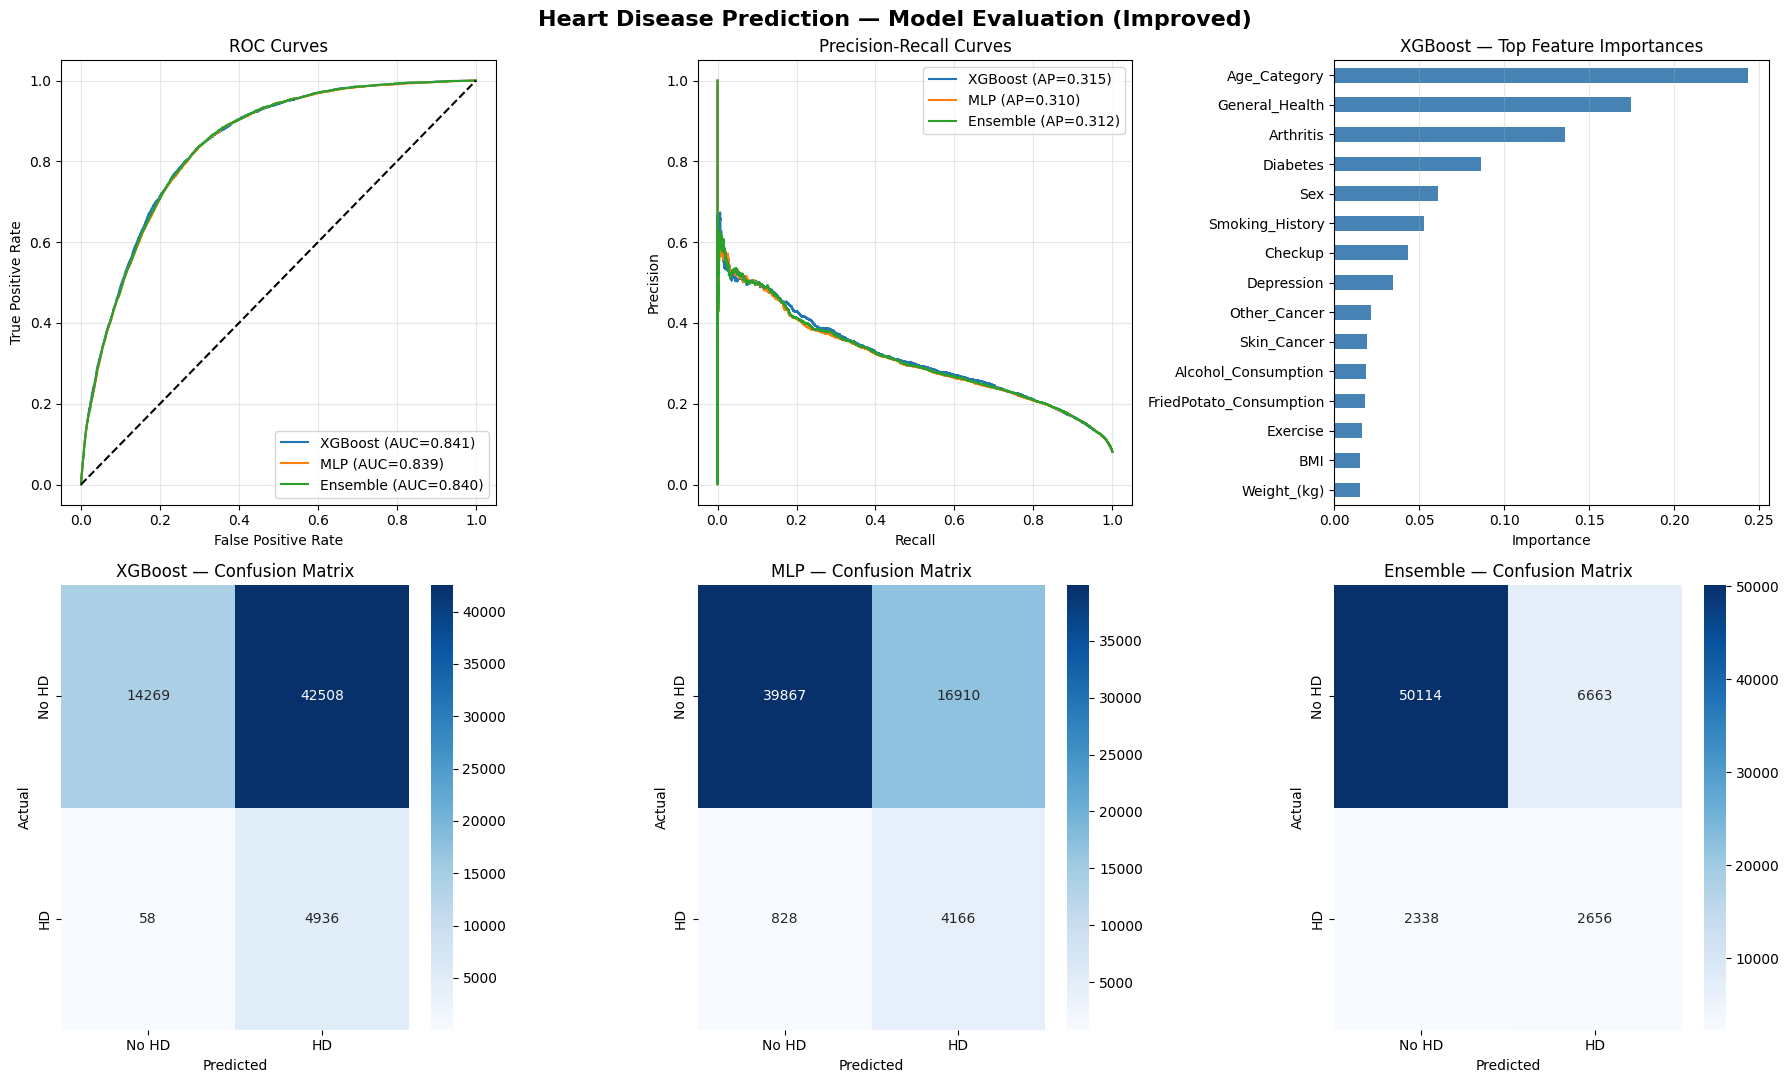


💾  Models saved to ./saved_models/

╔══════════════════════════════════════════════════════════╗
║   ❤️   Heart Disease Risk Assessment Questionnaire   ❤️   ║
╚══════════════════════════════════════════════════════════╝
  Answer the questions below. All fields are required.

  1. How would you rate your general health?
    [1] Excellent
    [2] Very Good
    [3] Good
    [4] Fair
    [5] Poor

  2. When was your last medical checkup?
    [1] Within the past year
    [2] Within the past 2 years
    [3] Within the past 5 years
    [4] 5 or more years ago
    [5] Never

  3. Do you exercise (physical activity in past 30 days)?
    [1] Yes
    [2] No

  4. Have you ever been diagnosed with skin cancer?
    [1] No
    [2] Yes

  5. Have you ever been diagnosed with any other cancer?
    [1] No
    [2] Yes

  6. Have you been diagnosed with a depressive disorder?
    [1] No
    [2] Yes

  7. Diabetes status?
    [1] No
    [2] No, pre-diabetes or borderline diabetes
    [3] Yes, but female 

In [8]:
# ─────────────────────────────────────────────────────────────────
# 7.  MAIN ENTRY POINT
# ─────────────────────────────────────────────────────────────────
def main():
    print("\n" + "═"*62)
    print("   Heart Disease Prediction — XGBoost + MLP + Stacking")
    print("   (IMPROVED VERSION)")
    print("═"*62)
 
    # Check if improved model exists
    models_exist = (
        os.path.exists(f"{MODEL_DIR}/xgb_heart.json") and
        os.path.exists(f"{MODEL_DIR}/meta_clf.pkl")
    )
 
    if models_exist:
        ans = input("\n  Saved models found. Use them? (y/n, default y): ").strip().lower()
        if ans in ("", "y", "yes"):
            print("  Loading saved models …")
            xgb_model, mlp_model, meta_clf, scaler, threshold, selected_features = load_models()
        else:
            X, y, feature_cols = load_and_preprocess(CSV_PATH)
            xgb_model, mlp_model, meta_clf, scaler, threshold, selected_features = train_models(X, y, feature_cols)
    else:
        print(f"\n  No saved models found — will train from: {CSV_PATH}")
        if not os.path.exists(CSV_PATH):
            print(f"\n  ❌  Dataset not found at: {CSV_PATH}")
            print("      Please set CSV_PATH at the top of this script.")
            sys.exit(1)
        X, y, feature_cols = load_and_preprocess(CSV_PATH)
        xgb_model, mlp_model, meta_clf, scaler, threshold, selected_features = train_models(X, y, feature_cols)
 
    # Run questionnaire (loop)
    while True:
        run_questionnaire(xgb_model, mlp_model, meta_clf, scaler, threshold, selected_features)
        again = input("\n  Run another prediction? (y/n): ").strip().lower()
        if again not in ("y", "yes"):
            print("\n  Thank you for using the Heart Disease Prediction System. Stay healthy! ❤️\n")
            break
 
 
if __name__ == "__main__":
    main()